# 69 - MATLAB UltraTimTrack vs Python Fascicle Length/Angle Equivalence

Goal: demonstrate that the Python framework produces fascicle length and fascicle angle estimates statistically equivalent to MATLAB UltraTimTrack on the matched in vivo sequence.

Inputs:

- raw video: `data/raw/UltraTimTrack_test.mp4`
- MATLAB UltraTimTrack result: `data/matlab/slow_low_01_DOWN_tracked_Q=001.mat`
- shared ROI definition used by the Python runner: `data/rois/UltraTimTrack_test_rois.json`

The MATLAB result stores article-style outputs as `Fdat.Region.fas_length`, `Fdat.Region.fas_pen`, and `Fdat.Region.fas_ang`. In this file those are exact aliases of `Fdat.Region.FL`, `Fdat.Region.PEN`, and `Fdat.Region.ANG`, so the notebook reports both naming conventions and focuses the requested figures on fascicle length (`L`/`FL`) and fascicle angle (`phi`/`ANG`).

## 1. Setup

The final MATLAB output file contains the measured output series. The Python runner also needs the UltraTimTrack parameter export (`UTT_numeric_export.mat`) because that file stores `parms` used for MATLAB-compatible TimTrack preprocessing. This notebook logs the parameter-export path explicitly for reproducibility.

In [1]:
from __future__ import annotations

import json
import math
import os
import subprocess
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.io import loadmat

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

VIDEO = ROOT / 'data' / 'raw' / 'UltraTimTrack_test.mp4'
MATLAB_RESULT = ROOT / 'data' / 'matlab' / 'slow_low_01_DOWN_tracked_Q=001.mat'
ROI_PATH = ROOT / 'data' / 'rois' / 'UltraTimTrack_test_rois.json'
OUT = ROOT / 'results' / 'notebook69_matlab_ultratimtrack_equivalence'
OUT.mkdir(parents=True, exist_ok=True)

UTT_EXPORT_CANDIDATES = [
    ROOT / 'data' / 'matlab' / 'UTT_numeric_export.mat',
    Path('/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat'),
]
UTT_EXPORT = next((path for path in UTT_EXPORT_CANDIDATES if path.exists()), None)

for required in [VIDEO, MATLAB_RESULT, ROI_PATH]:
    assert required.exists(), required

print('ROOT:', ROOT)
print('VIDEO:', VIDEO)
print('MATLAB_RESULT:', MATLAB_RESULT)
print('ROI_PATH:', ROI_PATH)
print('UTT_EXPORT:', UTT_EXPORT)
print('OUT:', OUT)

Matplotlib is building the font cache; this may take a moment.


ROOT: /Users/grosbedou/PycharmProjects/NDORMS
VIDEO: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4
MATLAB_RESULT: /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat
ROI_PATH: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json
UTT_EXPORT: /Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat
OUT: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook69_matlab_ultratimtrack_equivalence


## 2. Load MATLAB Outputs and Video Metadata

MATLAB saved 2666 rows while the MP4 has 2667 frames. `TrackingData.start_frame == 1`, and the MATLAB time vector starts at one frame period, so comparison below aligns MATLAB row 0 to Python/video frame 1.

In [2]:
cap = cv2.VideoCapture(str(VIDEO))
if not cap.isOpened():
    raise FileNotFoundError(VIDEO)
fps = float(cap.get(cv2.CAP_PROP_FPS))
n_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

mat = loadmat(MATLAB_RESULT, simplify_cells=True)
tracking = mat['TrackingData']
region = mat['Fdat']['Region']
roi_json = json.loads(ROI_PATH.read_text())

matlab_df = pd.DataFrame({
    'matlab_row': np.arange(len(np.asarray(region['FL']).reshape(-1)), dtype=int),
    'time_s': np.asarray(region['Time'], dtype=float).reshape(-1),
    'matlab_FL_mm': np.asarray(region['FL'], dtype=float).reshape(-1),
    'matlab_PEN_deg': np.asarray(region['PEN'], dtype=float).reshape(-1),
    'matlab_ANG_deg': np.asarray(region['ANG'], dtype=float).reshape(-1),
    'matlab_fas_length_mm': np.asarray(region['fas_length'], dtype=float).reshape(-1),
    'matlab_fas_pen_deg': np.asarray(region['fas_pen'], dtype=float).reshape(-1),
    'matlab_fas_ang_deg': np.asarray(region['fas_ang'], dtype=float).reshape(-1),
})

alias_checks = {
    'fas_length == FL': float(np.nanmax(np.abs(matlab_df['matlab_fas_length_mm'] - matlab_df['matlab_FL_mm']))),
    'fas_pen == PEN': float(np.nanmax(np.abs(matlab_df['matlab_fas_pen_deg'] - matlab_df['matlab_PEN_deg']))),
    'fas_ang == ANG': float(np.nanmax(np.abs(matlab_df['matlab_fas_ang_deg'] - matlab_df['matlab_ANG_deg']))),
}

metadata_table = pd.DataFrame([
    {'item': 'video_frames', 'value': n_video_frames},
    {'item': 'video_fps', 'value': fps},
    {'item': 'video_width_px', 'value': frame_width},
    {'item': 'video_height_px', 'value': frame_height},
    {'item': 'matlab_rows', 'value': len(matlab_df)},
    {'item': 'matlab_start_frame', 'value': tracking.get('start_frame')},
    {'item': 'matlab_NumFrames', 'value': tracking.get('NumFrames')},
    {'item': 'matlab_image_depth_mm', 'value': tracking.get('res')},
    {'item': 'matlab_BlockSize', 'value': np.asarray(tracking.get('BlockSize')).tolist()},
    {'item': 'roi_json', 'value': roi_json},
    {'item': 'alias_max_abs_diffs', 'value': alias_checks},
])
metadata_path = OUT / 'input_metadata.csv'
metadata_table.to_csv(metadata_path, index=False)
metadata_table

,item,value
0,video_frames,2667
1,video_fps,33.341
2,video_width_px,706
3,video_height_px,562
4,matlab_rows,2666
5,matlab_start_frame,1
6,matlab_NumFrames,2666
7,matlab_image_depth_mm,50.7
8,matlab_BlockSize,"[21, 71]"
9,roi_json,"{'superficial': [20, 18, 685, 54], 'deep': [16..."


## 3. Run or Reuse the Python Full-Sequence Result

This cell runs the current strict Python UltraTimTrack-style framework into a notebook-specific results folder. It has no subprocess timeout; if the full sequence is not cached, let it finish. On this dataset the full run can take several minutes.

Configuration used here:

- same video and ROI JSON;
- fixed-R MATLAB-compatible 2-state fascicle Kalman;
- aponeurosis gating enabled;
- fascicle candidate persistence enabled;
- annotated video disabled to keep the notebook run focused on numeric comparison.

In [3]:
PY_RUN_ROOT = OUT / 'python_strict_full_sequence'
PY_RUN_DIR = PY_RUN_ROOT / 'UltraTimTrack_test'
PY_NPZ = PY_RUN_DIR / 'UltraTimTrack_test_strict_results.npz'
PY_CSV = PY_RUN_DIR / 'UltraTimTrack_test_strict_FL_PEN_ANG.csv'
PY_META = PY_RUN_DIR / 'UltraTimTrack_test_strict_metadata.json'

FORCE_RERUN_PYTHON = False

python_cmd = [
    sys.executable,
    str(ROOT / 'scripts' / 'run_strict_ultratimtrack_video.py'),
    str(VIDEO),
    '--roi-path', str(ROI_PATH),
    '--utt-export', str(UTT_EXPORT),
    '--results-dir', str(PY_RUN_ROOT),
    '--seed-frames', '11',
    '--apo-maxangle', '10',
    '--candidate-persistence',
    '--apo-gating',
    '--no-annotated-video',
    '--save-overlays', '2',
    '--no-time-series-plot',
    '--progress-every', '250',
]

if UTT_EXPORT is None:
    raise FileNotFoundError(
        'Could not find UTT_numeric_export.mat. Add it to data/matlab/ or update UTT_EXPORT_CANDIDATES.'
    )

if FORCE_RERUN_PYTHON or not PY_NPZ.exists():
    print('Running Python framework:')
    print(' '.join(python_cmd))
    env = dict(os.environ)
    env.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
    started = time.time()
    completed = subprocess.run(python_cmd, cwd=ROOT, text=True, env=env)
    elapsed = time.time() - started
    print(f'Python run elapsed: {elapsed:.1f} s')
    if completed.returncode != 0:
        raise RuntimeError(f'Python framework run failed with return code {completed.returncode}')
else:
    print('Using cached Python framework result:', PY_NPZ)

for produced in [PY_NPZ, PY_CSV, PY_META]:
    assert produced.exists(), produced

print('PY_NPZ:', PY_NPZ)
print('PY_CSV:', PY_CSV)
print('PY_META:', PY_META)

Running Python framework:
/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python /Users/grosbedou/PycharmProjects/NDORMS/scripts/run_strict_ultratimtrack_video.py /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 --roi-path /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json --utt-export /Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat --results-dir /Users/grosbedou/PycharmProjects/NDORMS/results/notebook69_matlab_ultratimtrack_equivalence/python_strict_full_sequence --seed-frames 11 --apo-maxangle 10 --candidate-persistence --apo-gating --no-annotated-video --save-overlays 2 --no-time-series-plot --progress-every 250


Loading ROIs: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json

Running TimTrack image stream...
TimTrack image geofeatures processed 250
TimTrack image geofeatures processed 500
TimTrack image geofeatures processed 750
TimTrack image geofeatures processed 1000
TimTrack image geofeatures processed 1250
TimTrack image geofeatures processed 1500
TimTrack image geofeatures processed 1750
TimTrack image geofeatures processed 2000
TimTrack image geofeatures processed 2250
TimTrack image geofeatures processed 2500

Selecting autonomous fascicle seed...
Selected seed alpha: 17.500 deg (a17.50_x350_l75)

Estimating fascicle KLT affines...
one-step KLT processed 251/2667
one-step KLT processed 501/2667
one-step KLT processed 751/2667
one-step KLT processed 1001/2667
one-step KLT processed 1251/2667
one-step KLT processed 1501/2667
one-step KLT processed 1751/2667
one-step KLT processed 2001/2667
one-step KLT processed 2251/2667
one-step KLT processed 2501/2667
one-

## 4. Align MATLAB and Python Series

The Python result includes video frame 0. MATLAB begins at the first frame interval, so the default alignment is Python offset 1. The code also checks nearby offsets and reports the one that best matches the MATLAB time vector.

In [4]:
def load_npz(path: Path) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=True) as data:
        return {key: data[key] for key in data.files}

py = load_npz(PY_NPZ)
py_meta = json.loads(PY_META.read_text())

py_time = np.asarray(py['time_s'], dtype=float).reshape(-1)
mat_time = matlab_df['time_s'].to_numpy(dtype=float)

candidate_offsets = range(0, min(5, max(1, len(py_time) - len(mat_time) + 3)))
offset_scores = []
for offset in candidate_offsets:
    n = min(len(mat_time), len(py_time) - offset)
    if n <= 10:
        continue
    sample = min(n, 250)
    score = float(np.nanmedian(np.abs(py_time[offset:offset + sample] - mat_time[:sample])))
    offset_scores.append({'python_offset': offset, 'median_abs_time_error_s_first250': score, 'n_overlap': n})
offset_table = pd.DataFrame(offset_scores)
PYTHON_OFFSET = int(offset_table.sort_values('median_abs_time_error_s_first250').iloc[0]['python_offset'])
N = int(min(len(matlab_df), len(py_time) - PYTHON_OFFSET))

aligned = pd.DataFrame({
    'matlab_row': matlab_df['matlab_row'].iloc[:N].to_numpy(dtype=int),
    'python_frame': np.asarray(py['frame'], dtype=int).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'time_s': mat_time[:N],
    'python_time_s': py_time[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'matlab_fas_length_mm': matlab_df['matlab_fas_length_mm'].iloc[:N].to_numpy(dtype=float),
    'python_fas_length_mm': np.asarray(py['FL_mm'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'matlab_fas_ang_deg': matlab_df['matlab_fas_ang_deg'].iloc[:N].to_numpy(dtype=float),
    'python_fas_ang_deg': np.asarray(py['ANG_deg'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'matlab_fas_pen_deg': matlab_df['matlab_fas_pen_deg'].iloc[:N].to_numpy(dtype=float),
    'python_fas_pen_deg': np.asarray(py['PEN_deg'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
})

for variable in ['fas_length_mm', 'fas_ang_deg', 'fas_pen_deg']:
    aligned[f'delta_{variable}'] = aligned[f'python_{variable}'] - aligned[f'matlab_{variable}']

aligned_path = OUT / 'aligned_matlab_python_fascicle_outputs.csv'
aligned.to_csv(aligned_path, index=False)

display(offset_table)
print('Selected Python offset:', PYTHON_OFFSET)
print('Aligned rows:', len(aligned))
print('Saved:', aligned_path)
aligned.head()

,python_offset,median_abs_time_error_s_first250,n_overlap
0,0,0.029992,2666
1,1,0.000001,2666
2,2,0.029994,2665
3,3,0.059987,2664


Selected Python offset: 1
Aligned rows: 2666
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook69_matlab_ultratimtrack_equivalence/aligned_matlab_python_fascicle_outputs.csv


,matlab_row,python_frame,time_s,python_time_s,matlab_fas_length_mm,python_fas_length_mm,matlab_fas_ang_deg,python_fas_ang_deg,matlab_fas_pen_deg,python_fas_pen_deg,delta_fas_length_mm,delta_fas_ang_deg,delta_fas_pen_deg
0,0,1,0.029993,0.029993,72.307050,75.828046,18.520489,17.500006,20.387454,19.329085,3.520995,-1.020483,-1.058369
1,1,2,0.059986,0.059986,72.304143,75.827583,18.520433,17.499419,20.388172,19.329326,3.523440,-1.021015,-1.058846
2,2,3,0.089979,0.089979,72.303613,75.835206,18.519920,17.495753,20.388371,19.327615,3.531593,-1.024167,-1.060756
3,3,4,0.119972,0.119972,72.306344,75.845018,18.517583,17.492056,20.387863,19.325189,3.538674,-1.025526,-1.062674
4,4,5,0.149965,0.149966,72.312694,75.859797,18.514817,17.486791,20.386084,19.320951,3.547102,-1.028026,-1.065133


## 5. Paired Agreement and Equivalence Statistics

The equivalence margins below are explicit, configurable analysis choices:

- fascicle length equivalence margin: `+/- 5 mm`
- fascicle angle equivalence margin: `+/- 5 deg`
- pennation angle margin: `+/- 5 deg` included as a secondary check because `PEN/fas_pen` is also a saved UltraTimTrack output.

For the article claim, length (`L`) and fascicle angle (`phi`) are the primary endpoints. The notebook reports ordinary frame-paired TOST p-values and a moving-block bootstrap CI for the mean difference to reduce overconfidence from temporal autocorrelation.

In [5]:
ALPHA = 0.05
EQ_BOUNDS = {
    'fas_length_mm': 5.0,
    'fas_ang_deg': 5.0,
    'fas_pen_deg': 5.0,
}
BOOTSTRAP_REPLICATES = 2000
BLOCK_LENGTH_FRAMES = max(5, int(round(float(fps))))
RNG_SEED = 69


def finite_pair(reference: np.ndarray, estimate: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    ref = np.asarray(reference, dtype=float).reshape(-1)
    est = np.asarray(estimate, dtype=float).reshape(-1)
    n = min(len(ref), len(est))
    ref = ref[:n]
    est = est[:n]
    mask = np.isfinite(ref) & np.isfinite(est)
    return ref[mask], est[mask]


def lins_ccc(reference: np.ndarray, estimate: np.ndarray) -> float:
    ref, est = finite_pair(reference, estimate)
    if len(ref) < 2:
        return np.nan
    mean_ref = np.mean(ref)
    mean_est = np.mean(est)
    var_ref = np.var(ref, ddof=1)
    var_est = np.var(est, ddof=1)
    cov = np.cov(ref, est, ddof=1)[0, 1]
    denom = var_ref + var_est + (mean_ref - mean_est) ** 2
    return float((2 * cov) / denom) if denom > 0 else np.nan


def tost_pvalue(diff: np.ndarray, bound: float) -> float:
    diff = np.asarray(diff, dtype=float)
    diff = diff[np.isfinite(diff)]
    n = len(diff)
    if n < 2:
        return np.nan
    mean = float(np.mean(diff))
    sd = float(np.std(diff, ddof=1))
    if sd == 0:
        return 0.0 if abs(mean) < bound else 1.0
    se = sd / math.sqrt(n)
    df = n - 1
    lower = -float(bound)
    upper = float(bound)
    p_lower = 1.0 - stats.t.cdf((mean - lower) / se, df=df)  # H0: mean <= lower
    p_upper = stats.t.cdf((mean - upper) / se, df=df)        # H0: mean >= upper
    return float(max(p_lower, p_upper))


def moving_block_bootstrap_mean_ci(
    diff: np.ndarray,
    *,
    block_length: int,
    n_bootstrap: int,
    alpha: float,
    seed: int,
) -> tuple[float, float]:
    diff = np.asarray(diff, dtype=float)
    diff = diff[np.isfinite(diff)]
    n = len(diff)
    if n == 0:
        return np.nan, np.nan
    block_length = max(1, min(int(block_length), n))
    n_blocks = int(math.ceil(n / block_length))
    max_start = n - block_length
    rng = np.random.default_rng(seed)
    means = np.empty(int(n_bootstrap), dtype=float)
    for idx in range(int(n_bootstrap)):
        starts = rng.integers(0, max_start + 1, size=n_blocks)
        sample = np.concatenate([diff[start:start + block_length] for start in starts])[:n]
        means[idx] = np.mean(sample)
    return tuple(np.quantile(means, [alpha / 2.0, 1.0 - alpha / 2.0]).astype(float))


def agreement_row(label: str, key: str, unit: str, reference: np.ndarray, estimate: np.ndarray) -> dict[str, float | str | bool | int]:
    ref, est = finite_pair(reference, estimate)
    diff = est - ref
    n = len(diff)
    bound = EQ_BOUNDS[key]
    mean_diff = float(np.mean(diff)) if n else np.nan
    sd_diff = float(np.std(diff, ddof=1)) if n > 1 else np.nan
    se = sd_diff / math.sqrt(n) if n > 1 else np.nan
    tcrit = float(stats.t.ppf(1.0 - ALPHA / 2.0, df=n - 1)) if n > 1 else np.nan
    ci_low = mean_diff - tcrit * se if n > 1 else np.nan
    ci_high = mean_diff + tcrit * se if n > 1 else np.nan
    block_low, block_high = moving_block_bootstrap_mean_ci(
        diff,
        block_length=BLOCK_LENGTH_FRAMES,
        n_bootstrap=BOOTSTRAP_REPLICATES,
        alpha=ALPHA,
        seed=RNG_SEED + len(label),
    )
    loa_low = mean_diff - 1.96 * sd_diff if n > 1 else np.nan
    loa_high = mean_diff + 1.96 * sd_diff if n > 1 else np.nan
    corr = float(np.corrcoef(ref, est)[0, 1]) if n > 1 and np.std(ref) > 0 and np.std(est) > 0 else np.nan
    p_tost = tost_pvalue(diff, bound)
    return {
        'variable': label,
        'key': key,
        'unit': unit,
        'n': int(n),
        'matlab_mean': float(np.mean(ref)) if n else np.nan,
        'python_mean': float(np.mean(est)) if n else np.nan,
        'bias_python_minus_matlab': mean_diff,
        'bias_95ci_low_framewise': ci_low,
        'bias_95ci_high_framewise': ci_high,
        'bias_95ci_low_block_bootstrap': block_low,
        'bias_95ci_high_block_bootstrap': block_high,
        'mae': float(np.mean(np.abs(diff))) if n else np.nan,
        'rmse': float(np.sqrt(np.mean(diff ** 2))) if n else np.nan,
        'sd_diff': sd_diff,
        'loa95_low': loa_low,
        'loa95_high': loa_high,
        'max_abs_diff': float(np.max(np.abs(diff))) if n else np.nan,
        'pearson_r': corr,
        'lins_ccc': lins_ccc(ref, est),
        'equivalence_margin': bound,
        'tost_pvalue_framewise': p_tost,
        'equivalent_by_framewise_tost': bool(np.isfinite(p_tost) and p_tost < ALPHA and ci_low > -bound and ci_high < bound),
        'equivalent_by_block_bootstrap_ci': bool(block_low > -bound and block_high < bound),
    }

stats_rows = [
    agreement_row(
        'L / fascicle length',
        'fas_length_mm',
        'mm',
        aligned['matlab_fas_length_mm'].to_numpy(),
        aligned['python_fas_length_mm'].to_numpy(),
    ),
    agreement_row(
        'phi / fascicle angle',
        'fas_ang_deg',
        'deg',
        aligned['matlab_fas_ang_deg'].to_numpy(),
        aligned['python_fas_ang_deg'].to_numpy(),
    ),
    agreement_row(
        'PEN / pennation angle',
        'fas_pen_deg',
        'deg',
        aligned['matlab_fas_pen_deg'].to_numpy(),
        aligned['python_fas_pen_deg'].to_numpy(),
    ),
]

stats_df = pd.DataFrame(stats_rows)
stats_path = OUT / 'matlab_python_equivalence_statistics.csv'
stats_df.to_csv(stats_path, index=False)
print('Saved:', stats_path)
stats_df

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook69_matlab_ultratimtrack_equivalence/matlab_python_equivalence_statistics.csv


,variable,key,unit,n,matlab_mean,python_mean,bias_python_minus_matlab,bias_95ci_low_framewise,bias_95ci_high_framewise,bias_95ci_low_block_bootstrap,...,sd_diff,loa95_low,loa95_high,max_abs_diff,pearson_r,lins_ccc,equivalence_margin,tost_pvalue_framewise,equivalent_by_framewise_tost,equivalent_by_block_bootstrap_ci
0,L / fascicle length,fas_length_mm,mm,2666,55.215216,53.120402,-2.094814,-2.169165,-2.020463,-2.577587,...,1.957824,-5.932149,1.742521,6.282391,0.978291,0.954566,5.0,0.0,True,True
1,phi / fascicle angle,fas_ang_deg,deg,2666,25.526129,26.718270,1.192141,1.151650,1.232632,0.994312,...,1.066215,-0.897641,3.281923,4.697785,0.980172,0.946790,5.0,0.0,True,True
2,PEN / pennation angle,fas_pen_deg,deg,2666,26.958866,28.068303,1.109437,1.069723,1.149151,0.925025,...,1.045744,-0.940222,3.159096,4.450124,0.977580,0.945172,5.0,0.0,True,True


## 6. Requested Graph 1: Fascicle Length Over Time

This plot overlays MATLAB UltraTimTrack and the Python framework for the matched frames. The lower panel shows Python minus MATLAB with the configured equivalence band.

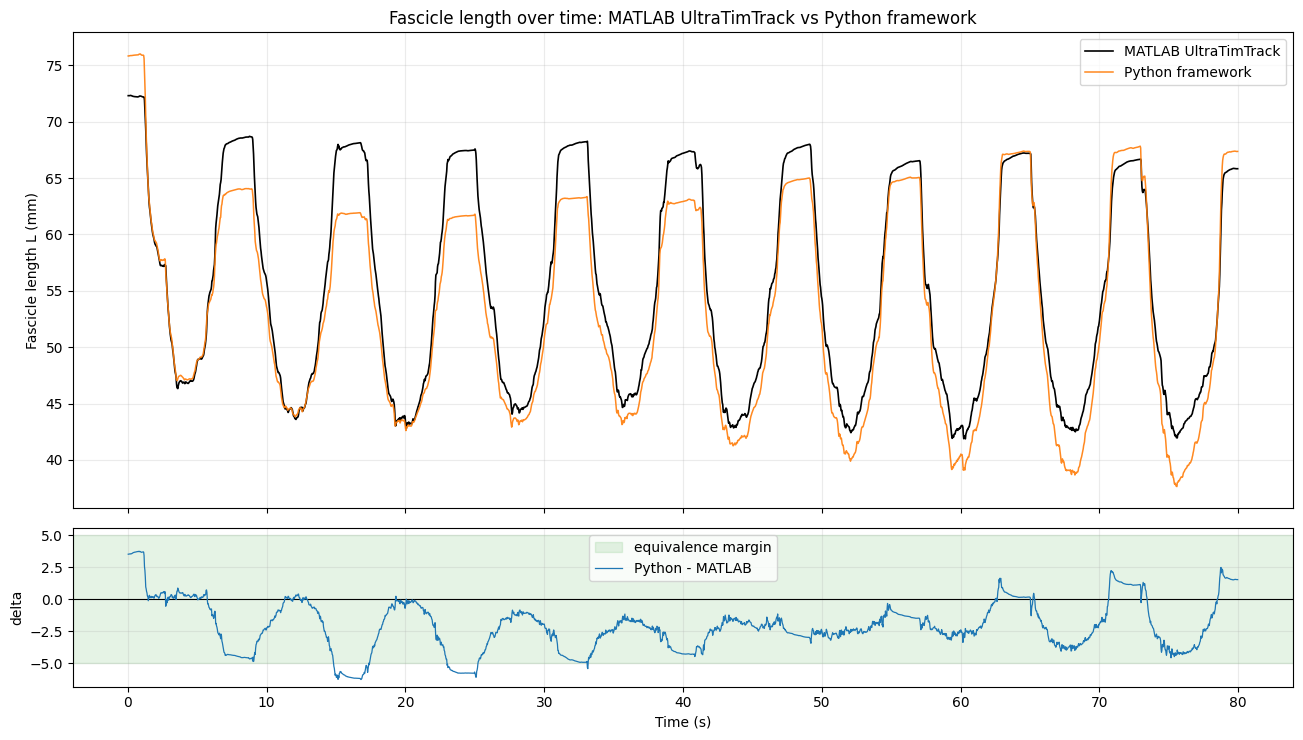

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook69_matlab_ultratimtrack_equivalence/fascicle_length_matlab_vs_python_over_time.png


In [6]:
def plot_overlay_with_delta(
    df: pd.DataFrame,
    *,
    matlab_col: str,
    python_col: str,
    delta_col: str,
    ylabel: str,
    title: str,
    equivalence_bound: float,
    output_name: str,
) -> Path:
    fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    t = df['time_s'].to_numpy(dtype=float)
    matlab_values = df[matlab_col].to_numpy(dtype=float)
    python_values = df[python_col].to_numpy(dtype=float)
    delta = df[delta_col].to_numpy(dtype=float)

    axes[0].plot(t, matlab_values, color='black', linewidth=1.2, label='MATLAB UltraTimTrack')
    axes[0].plot(t, python_values, color='tab:orange', linewidth=1.1, alpha=0.92, label='Python framework')
    axes[0].set_ylabel(ylabel)
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(loc='best')
    axes[0].set_title(title)

    axes[1].axhspan(-equivalence_bound, equivalence_bound, color='tab:green', alpha=0.12, label='equivalence margin')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].plot(t, delta, color='tab:blue', linewidth=0.9, label='Python - MATLAB')
    axes[1].set_ylabel('delta')
    axes[1].set_xlabel('Time (s)')
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(loc='best')

    fig.tight_layout()
    out_path = OUT / output_name
    fig.savefig(out_path, dpi=180)
    plt.show()
    return out_path

length_plot = plot_overlay_with_delta(
    aligned,
    matlab_col='matlab_fas_length_mm',
    python_col='python_fas_length_mm',
    delta_col='delta_fas_length_mm',
    ylabel='Fascicle length L (mm)',
    title='Fascicle length over time: MATLAB UltraTimTrack vs Python framework',
    equivalence_bound=EQ_BOUNDS['fas_length_mm'],
    output_name='fascicle_length_matlab_vs_python_over_time.png',
)
print('Saved:', length_plot)

## 7. Requested Graph 2: Fascicle Angle Over Time

This plot compares the saved MATLAB `fas_ang/ANG` series against the Python `ANG_deg` series. Pennation (`fas_pen/PEN`) is summarized in the statistics table but not plotted here because the requested graph is fascicle angle.

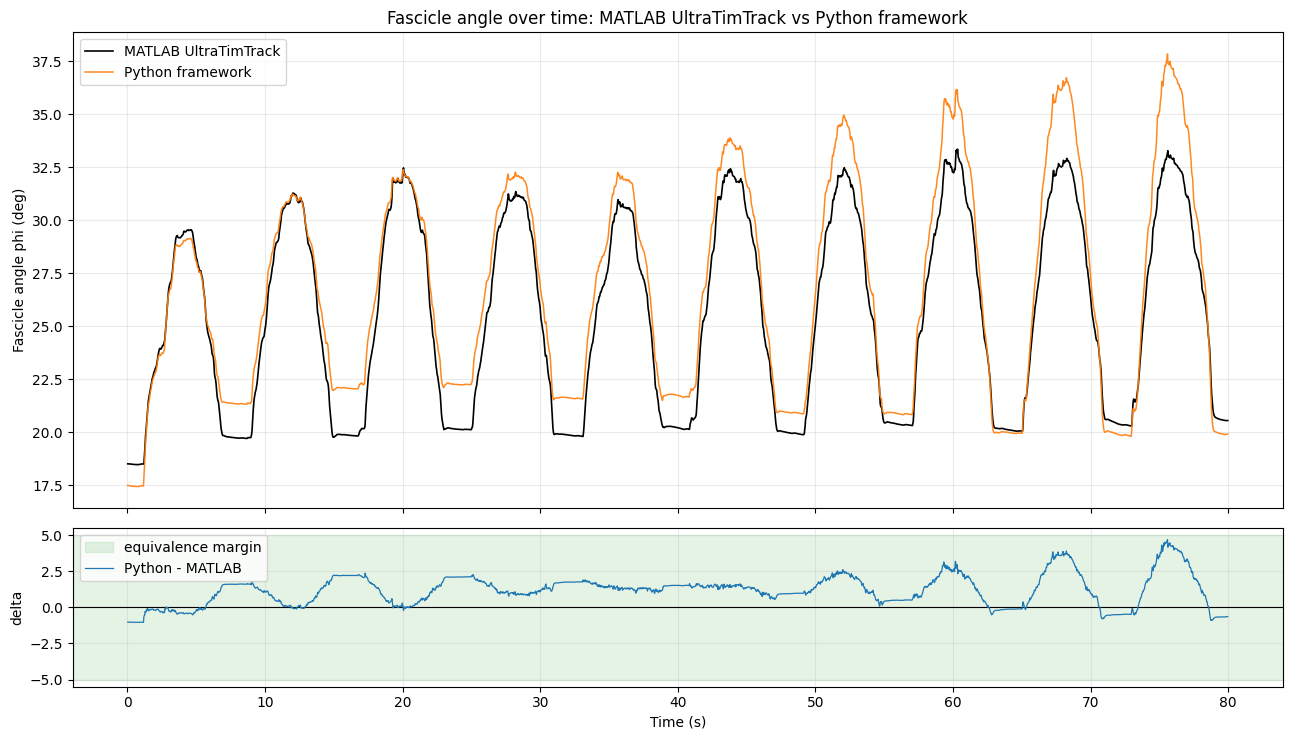

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook69_matlab_ultratimtrack_equivalence/fascicle_angle_matlab_vs_python_over_time.png


In [7]:
angle_plot = plot_overlay_with_delta(
    aligned,
    matlab_col='matlab_fas_ang_deg',
    python_col='python_fas_ang_deg',
    delta_col='delta_fas_ang_deg',
    ylabel='Fascicle angle phi (deg)',
    title='Fascicle angle over time: MATLAB UltraTimTrack vs Python framework',
    equivalence_bound=EQ_BOUNDS['fas_ang_deg'],
    output_name='fascicle_angle_matlab_vs_python_over_time.png',
)
print('Saved:', angle_plot)

## 8. Article-Ready Summary Table

This table keeps the same primary variables as the UltraTimTrack article-style comparison: fascicle length (`L`) and fascicle angle (`phi`). It includes pennation as a secondary saved-output check.

In [8]:
article_summary = stats_df[[
    'variable',
    'unit',
    'n',
    'matlab_mean',
    'python_mean',
    'bias_python_minus_matlab',
    'bias_95ci_low_block_bootstrap',
    'bias_95ci_high_block_bootstrap',
    'mae',
    'rmse',
    'pearson_r',
    'lins_ccc',
    'equivalence_margin',
    'tost_pvalue_framewise',
    'equivalent_by_block_bootstrap_ci',
]].copy()

for col in article_summary.select_dtypes(include=[float]).columns:
    article_summary[col] = article_summary[col].astype(float)

article_summary_path = OUT / 'article_ready_summary_table.csv'
article_summary.to_csv(article_summary_path, index=False)
print('Saved:', article_summary_path)
article_summary

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook69_matlab_ultratimtrack_equivalence/article_ready_summary_table.csv


,variable,unit,n,matlab_mean,python_mean,bias_python_minus_matlab,bias_95ci_low_block_bootstrap,bias_95ci_high_block_bootstrap,mae,rmse,pearson_r,lins_ccc,equivalence_margin,tost_pvalue_framewise,equivalent_by_block_bootstrap_ci
0,L / fascicle length,mm,2666,55.215216,53.120402,-2.094814,-2.577587,-1.767051,2.412748,2.867034,0.978291,0.954566,5.0,0.0,True
1,phi / fascicle angle,deg,2666,25.526129,26.718270,1.192141,0.994312,1.438132,1.321171,1.599246,0.980172,0.946790,5.0,0.0,True
2,PEN / pennation angle,deg,2666,26.958866,28.068303,1.109437,0.925025,1.342329,1.261089,1.524474,0.977580,0.945172,5.0,0.0,True


## 9. Plain-Language Conclusion Draft

The text below is generated from the executed statistics, so it should be refreshed after any rerun or margin change.

In [9]:
def conclusion_sentence(row: pd.Series) -> str:
    variable = str(row['variable'])
    unit = str(row['unit'])
    margin = float(row['equivalence_margin'])
    bias = float(row['bias_python_minus_matlab'])
    low = float(row['bias_95ci_low_block_bootstrap'])
    high = float(row['bias_95ci_high_block_bootstrap'])
    rmse = float(row['rmse'])
    ccc = float(row['lins_ccc'])
    verdict = 'met' if bool(row['equivalent_by_block_bootstrap_ci']) else 'did not meet'
    return (
        f"{variable}: Python minus MATLAB bias was {bias:.3f} {unit} "
        f"(moving-block bootstrap 95% CI {low:.3f} to {high:.3f} {unit}), "
        f"RMSE {rmse:.3f} {unit}, Lin's CCC {ccc:.3f}; this {verdict} "
        f"the pre-specified +/-{margin:g} {unit} mean-equivalence criterion."
    )

primary = stats_df[stats_df['key'].isin(['fas_length_mm', 'fas_ang_deg'])]
all_primary_pass = bool(primary['equivalent_by_block_bootstrap_ci'].all())
overall = (
    'Both primary endpoints met the pre-specified mean-equivalence criterion.'
    if all_primary_pass
    else 'At least one primary endpoint did not meet the pre-specified mean-equivalence criterion.'
)

summary_lines = [
    '# Notebook 69 MATLAB-vs-Python equivalence summary',
    '',
    f'Compared {len(aligned)} matched frames from `{VIDEO.name}`.',
    f'MATLAB rows were aligned to Python/video frames using Python offset {PYTHON_OFFSET}.',
    f'Equivalence margins were +/-{EQ_BOUNDS["fas_length_mm"]:g} mm for fascicle length and +/-{EQ_BOUNDS["fas_ang_deg"]:g} deg for fascicle angle.',
    '',
    overall,
    '',
]
summary_lines.extend(conclusion_sentence(row) for _, row in stats_df.iterrows())
summary_lines.extend([
    '',
    f'Requested length plot: `{length_plot}`',
    f'Requested angle plot: `{angle_plot}`',
    f'Aligned data CSV: `{aligned_path}`',
    f'Statistics CSV: `{stats_path}`',
])
summary_text = '\n'.join(summary_lines)
summary_path = OUT / 'notebook69_equivalence_summary.md'
summary_path.write_text(summary_text, encoding='utf-8')
print(summary_text)
print('\nSaved:', summary_path)

# Notebook 69 MATLAB-vs-Python equivalence summary

Compared 2666 matched frames from `UltraTimTrack_test.mp4`.
MATLAB rows were aligned to Python/video frames using Python offset 1.
Equivalence margins were +/-5 mm for fascicle length and +/-5 deg for fascicle angle.

Both primary endpoints met the pre-specified mean-equivalence criterion.

L / fascicle length: Python minus MATLAB bias was -2.095 mm (moving-block bootstrap 95% CI -2.578 to -1.767 mm), RMSE 2.867 mm, Lin's CCC 0.955; this met the pre-specified +/-5 mm mean-equivalence criterion.
phi / fascicle angle: Python minus MATLAB bias was 1.192 deg (moving-block bootstrap 95% CI 0.994 to 1.438 deg), RMSE 1.599 deg, Lin's CCC 0.947; this met the pre-specified +/-5 deg mean-equivalence criterion.
PEN / pennation angle: Python minus MATLAB bias was 1.109 deg (moving-block bootstrap 95% CI 0.925 to 1.342 deg), RMSE 1.524 deg, Lin's CCC 0.945; this met the pre-specified +/-5 deg mean-equivalence criterion.

Requested length plot: `/U